## Quantum Teleportation  

The goal of this method is to transmit a qubit from a sender (commonly named as Alice) to a receiver (commonly named as Bob).  
  
Alice and Bob share an entangled pair of qubits, A and B (this can be physically generated using photons, trapped ions, or superconducting circuits). Alice performs bell state measurement on her qubit from the entangled pair, and the qubit she wants to transmit. Alice then sends the result of her measurement (two classical bits) to Bob. Based on these bits, Bob applies the corresponding Pauli operation to his qubit, transforming it into the state that Alice wanted to teleport.  

State to teleport:


<IPython.core.display.Latex object>

State after Bell pair creation:


<IPython.core.display.Latex object>

State of the circuit after Alice's operations:


<IPython.core.display.Latex object>

Final state before measurement:


<IPython.core.display.Latex object>

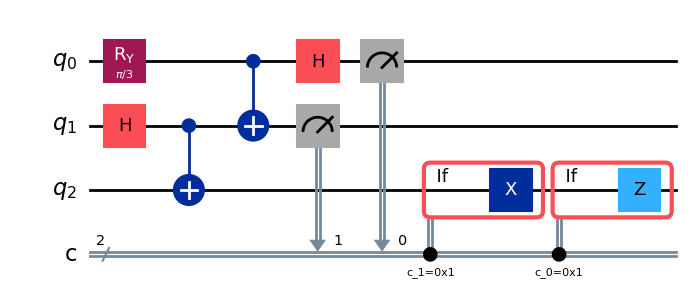

In [1]:
# Code for Quantum Teleportation Protocol
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import array_to_latex
qc = QuantumCircuit(3, 2) # Create a quantum circuit with 3 qubits and 2 classical bits
from math import pi
# Creating an arbitary state to teleport
qc.ry(pi/3, 0)

print("State to teleport:")
display(Statevector(qc).draw('latex'))

# Create an entangled pair (Bell state) between qubit 1 and qubit 2
qc.h(1)  # Apply Hadamard gate to qubit 1
qc.cx(1, 2)  # Apply CNOT gate 

sv = Statevector(qc) 
print("State after Bell pair creation:")
display(sv.draw('latex'))

# Alice's operations
qc.cx(0, 1)
qc.h(0)
sv = Statevector(qc)
print("State of the circuit after Alice's operations:")
display(sv.draw('latex'))

# Teleportation without measurements
teleport = qc.copy()

teleport.cx(1,2)
teleport.cz(0,2)

print("Final state before measurement:")
display(Statevector(teleport).draw('latex'))

qc.measure([0,1],[0,1])

with qc.if_test((qc.clbits[1], 1)):
    qc.x(2)

with qc.if_test((qc.clbits[0], 1)):
    qc.z(2)

# Draw the circuit
qc.draw(output='mpl')  

In [2]:
from qiskit.quantum_info import partial_trace, state_fidelity

# Original state |psi>
psi = QuantumCircuit(1)
psi.ry(0.7, 0)
psi.rz(1.2, 0)

original_state = Statevector(psi)

# Extract Bob's qubit
final_state = Statevector(teleport)
bob_state = partial_trace(final_state, [0, 1])

fidelity = state_fidelity(original_state, bob_state)

print(f"\nFidelity = {fidelity:.12f}")


Fidelity = 0.792291851793


In [3]:
from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator()
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()
print(counts)

{'01': 271, '00': 242, '11': 259, '10': 252}


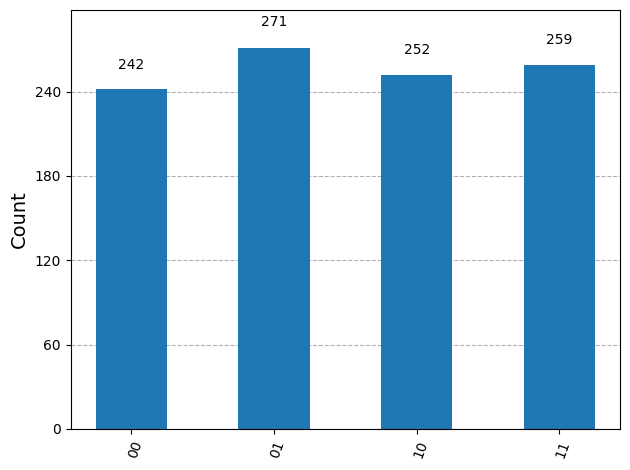

In [4]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)